# Weathering mediated bedrock erosion: Application

### Preliminaries

In [1]:
import wmbe, sympy as sy, numpy as np
# from matplotlib.pylab import plt
sy.init_printing(pretty_print=True,wrap_line=True)
from sympy import Eq
from wmbe.symbols import *

In [2]:
em = wmbe.theory.WeatheringMediatedErosion()

## Channel Wall

In [3]:
pdict = {
    v_r:1, v_b:0.05, h:1,
    z_vc:0.1, kappa_v:10, 
    w_r:1.5, k:1, z_wc:0.1, kappa_w:50
}
pdict
cw_highW = wmbe.solve1p1d.ChannelWall(em, pdict)
cw = cw_highW
cw.compute_vertical_profiles(n_pts=200)
cw.compute_cross_section()

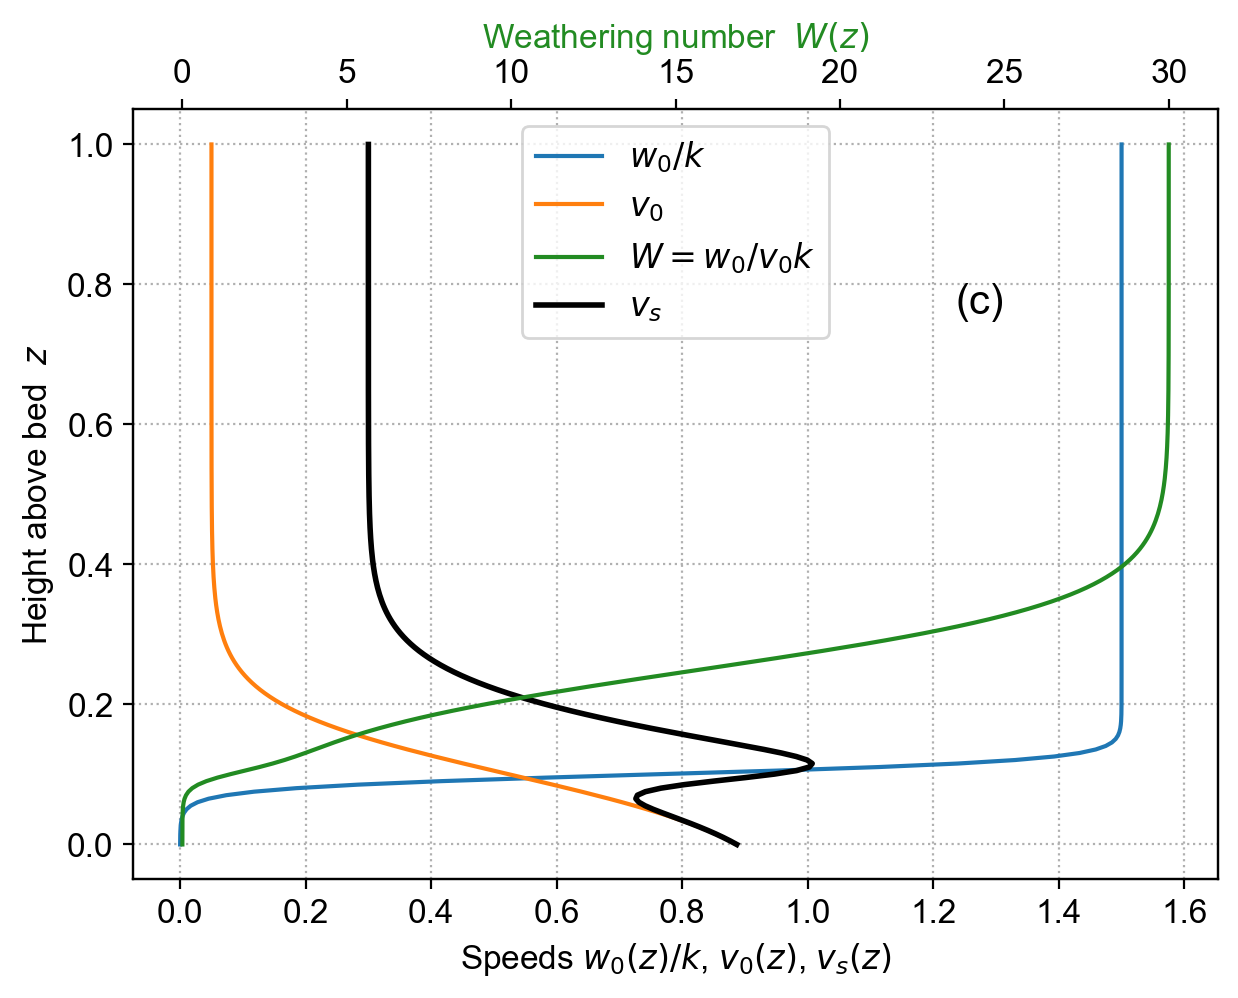

In [4]:
fig_z_w0_v0_vs_W_highW = wmbe.plot.create_figure("z_w0_v0_vs_W_highW")
wmbe.plot.plot_channel_w0_v0_W(fig_z_w0_v0_vs_W_highW, cw_highW,
                              text_label=((0.78,0.75),"(c)",15))

<>:8: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:8: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/3q/c6jmlmvn0950s6dp4v4z78sm0000gn/T/ipykernel_38335/453743674.py:8: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  cw_highW.eta0_array,"Surface weakness  $\eta_0$",


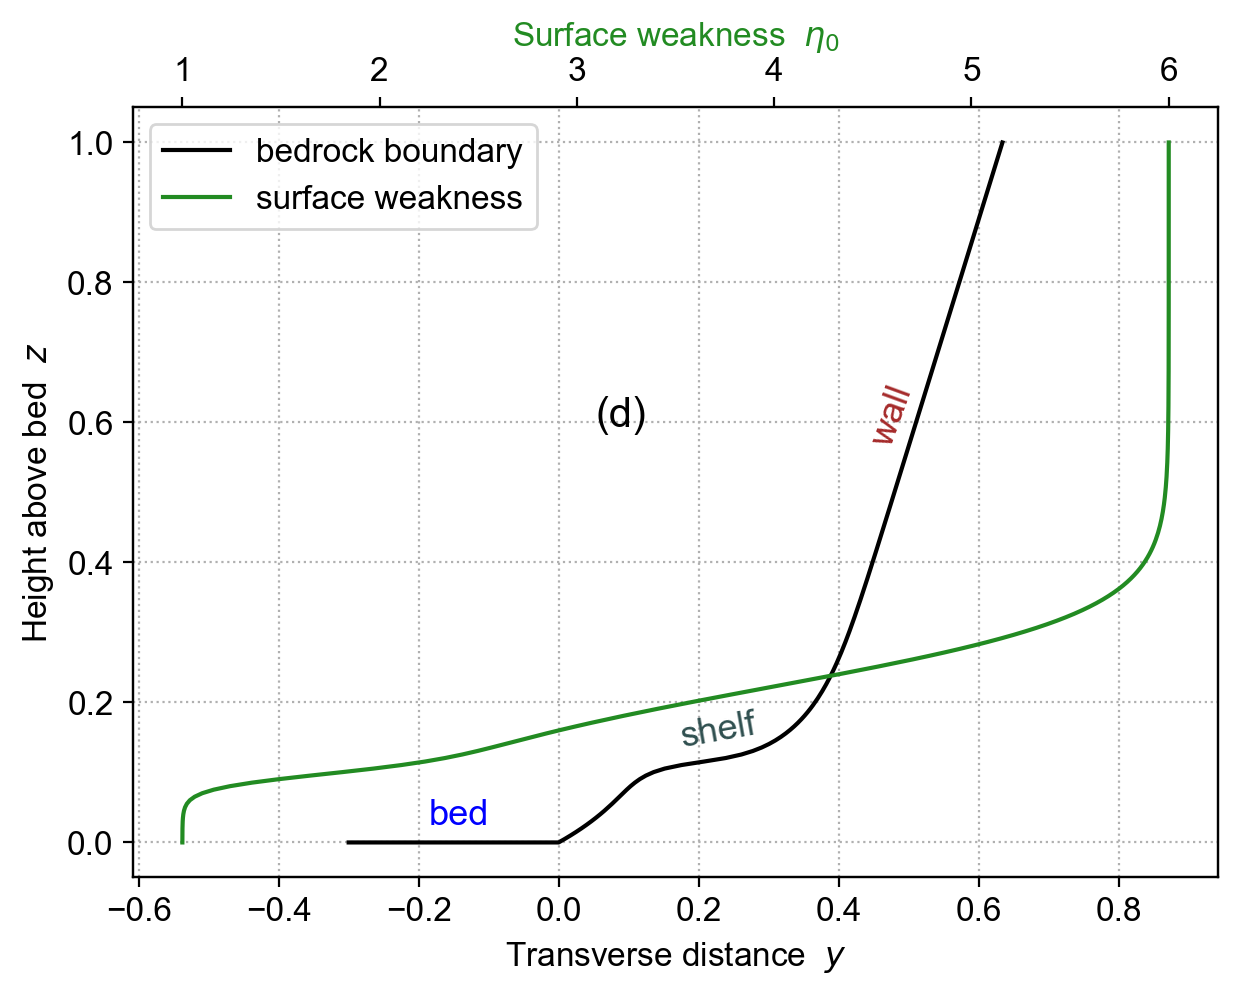

In [5]:
z_label = "Height above bed  $z$"
fig_z_y_highW = wmbe.plot.create_figure("z_y_highW")
wmbe.plot.plot_channel_generic(fig_z_y_highW,       
        [(cw_highW.ch_z_array, z_label,
          cw_highW.ch_y_array,"Transverse distance  $y$",
          "bedrock boundary"), 
        (cw_highW.z_array, "",
          cw_highW.eta0_array,"Surface weakness  $\eta_0$",
          "surface weakness")], 
          do_equal_aspect=True,
          text_labels=[((0.45,0.6),"(d)",15,"k",0),
                       ((0.3,0.08),"bed",13,"b",0),
                       ((0.54,0.19),"shelf",13,"darkslategray",10),
                       ((0.7,0.6),"wall",13,"brown",70)]
        )

In [6]:
pdict = {
    v_r:1, v_b:0.05, h:1,
    z_vc:0.1, kappa_v:10,
    w_r:0.11, k:1, z_wc:0.1, kappa_w:50
}
pdict
cw_transW = wmbe.solve1p1d.ChannelWall(em, pdict)
cw = cw_transW
cw.compute_vertical_profiles(n_pts=200)
cw.compute_cross_section()
# cw.v0_eqn_vr_h_z
# cw.w0_eqn_wr_z
# cw.vs_calibrated

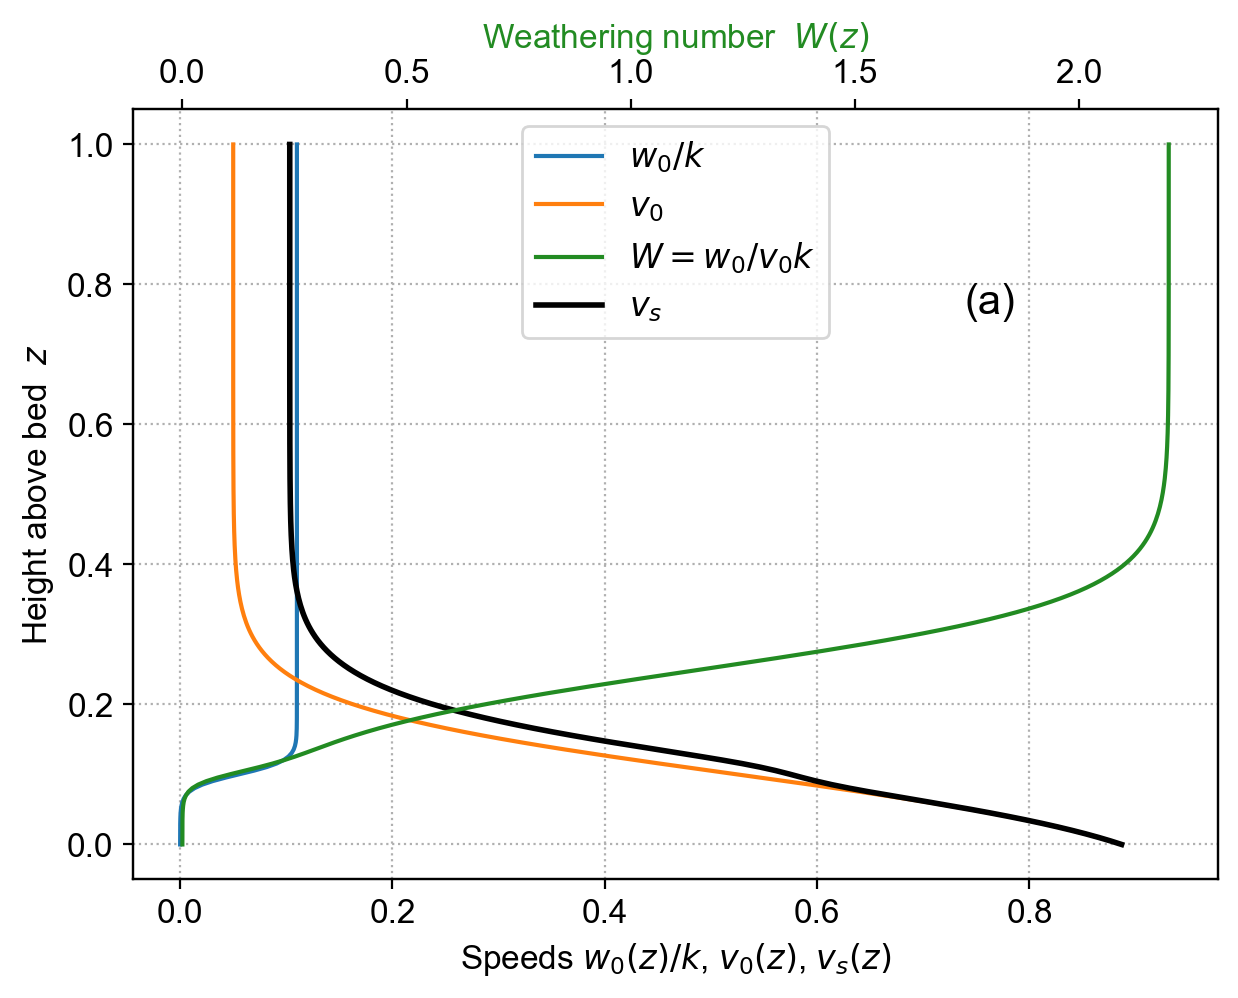

In [7]:
fig_z_w0_v0_vs_W_transW = wmbe.plot.create_figure("z_w0_v0_vs_W_transW")
wmbe.plot.plot_channel_w0_v0_W(fig_z_w0_v0_vs_W_transW, cw_transW,
                             text_label=((0.79,0.75),"(a)",15))

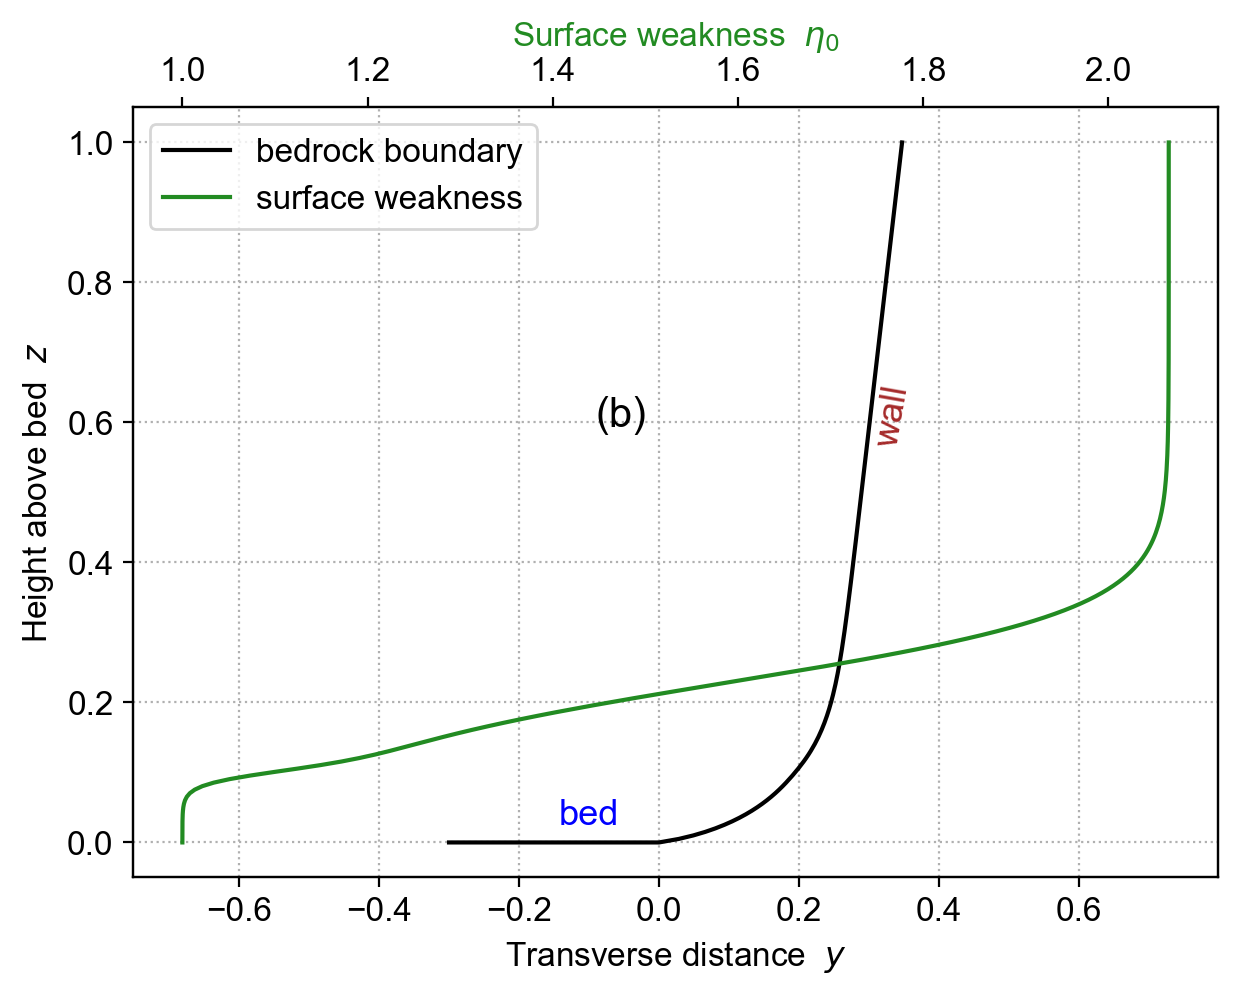

In [8]:
z_label = "Height above bed  $z$"
fig_z_y_transW = wmbe.plot.create_figure("z_y_transW")
wmbe.plot.plot_channel_generic(fig_z_y_transW, 
        [(cw_transW.ch_z_array, z_label,
          cw_transW.ch_y_array,r"Transverse distance  $y$",
          "bedrock boundary"), 
        (cw_transW.z_array, "",
          cw_transW.eta0_array,r"Surface weakness  $\eta_0$",
          "surface weakness")], 
          do_equal_aspect=True,
          text_labels=[((0.45,0.6),"(b)",15,"k",0),
                       ((0.42,0.08),"bed",13,"b",0),
                       ((0.7,0.6),"wall",13,"brown",80)]
                             )


## Save

In [9]:
results_dir = wmbe.save.create_plots_dir()

In [10]:
wmbe.save.export_plots(wmbe.plot.fdict,results_dir,"pdf")

Exported "z_w0_v0_vs_W_highW.pdf"
Exported "z_y_highW.pdf"
Exported "z_w0_v0_vs_W_transW.pdf"
Exported "z_y_transW.pdf"
